In [97]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from zipfile import ZipFile
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

#**DATA UNDERSTANDING**

In [43]:
users = pd.read_csv("content/Users.csv")
ratings = pd.read_csv("content/Ratings.csv")
books = pd.read_csv("content/Books.csv", low_memory=False)

print('Jumlah User: ', len(users['User-ID'].unique()))
print('Jumlah Buku: ', len(books['ISBN'].unique()))
print('Jumlah Penilaian Buku: ', len(ratings['ISBN'].unique()))

Jumlah User:  278858
Jumlah Buku:  271360
Jumlah Penilaian Buku:  340556


### Menampilkan Jumlah Entitas Utama dalam Dataset

- Langkah ini bertujuan untuk memahami skala data yang akan dianalisis.  
- Terdapat 278.858 user, 271.360 buku, dan 340.556 interaksi berupa penilaian buku oleh user.  
- Informasi ini penting untuk memberikan gambaran awal mengenai ukuran dataset serta hubungan antar entitas dalam sistem rekomendasi yang akan dibangun.

# **DATA CLEANING**

### Ratings

In [44]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


In [45]:
ratings.describe(include='all')

,User-ID,ISBN,Book-Rating
count,1.149780e+06,1149780,1.149780e+06
unique,NaN,340556,NaN
top,NaN,0971880107,NaN
freq,NaN,2502,NaN
mean,1.403864e+05,NaN,2.866950e+00
std,8.056228e+04,NaN,3.854184e+00
min,2.000000e+00,NaN,0.000000e+00
25%,7.034500e+04,NaN,0.000000e+00
50%,1.410100e+05,NaN,0.000000e+00
75%,2.110280e+05,NaN,7.000000e+00


In [46]:
ratings['Book-Rating'].value_counts()

,count
Book-Rating,
0,716109
8,103736
10,78610
7,76457
9,67541
5,50974
6,36924
4,8904
3,5996


**Interpretasi :**

- Berdasarkan hasil eksplorasi statistik terhadap kolom `Book-Rating`, ditemukan bahwa nilai **minimum hingga kuartil ke-2 (median) bernilai 0**, yang menunjukkan bahwa lebih dari 50% data rating tidak merepresentasikan preferensi pengguna.

- Distribusi ini menunjukkan adanya masalah sparsity dalam dataset, di mana sebagian besar interaksi user terhadap buku tidak menghasilkan penilaian yang bermakna.

- Untuk memperkuat analisis ini, dilakukan pengecekan lebih lanjut terhadap jumlah masing-masing nilai rating menggunakan `value_counts()`.

- Dari hasil tersebut ditemukan bahwa:
  - Sebanyak **716.109 rating (≈62%)** memiliki nilai 0.
  - Nilai rating dengan frekuensi tertinggi berikutnya adalah **rating 8 (103.736 rating)**, disusul oleh rating 10 dan 7.

Temuan ini menunjukkan bahwa data rating sangat **terdistribusi tidak merata**, dengan dominasi rating kosong yang signifikan. Oleh karena itu, data dengan nilai rating 0 akan dihapus dalam proses cleaning selanjutnya.


In [47]:
ratings = ratings[ratings['Book-Rating'] != 0]
ratings['Book-Rating'].value_counts()

,count
Book-Rating,
8,103736
10,78610
7,76457
9,67541
5,50974
6,36924
4,8904
3,5996
2,2759


### Books

In [48]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB


**INSIGHT :**

- Berdasarkan hasil analisis sebelumnya, ditemukan bahwa banyak buku memiliki jumlah rating yang sangat sedikit. Untuk meningkatkan kualitas rekomendasi dan efisiensi komputasi, dipilih sebanyak 10.000 buku dengan jumlah rating terbanyak.

- Langkah ini didasarkan pada asumsi bahwa buku yang sering dinilai lebih relevan untuk direkomendasikan karena lebih banyak pengguna yang telah berinteraksi dengan buku tersebut.


In [49]:
book_total = len(ratings['ISBN'].unique())
print("Jumlah Total ID Buku yang memiliki penilaian: ", book_total)

Jumlah Total ID Buku yang memiliki penilaian:  185973


### Pembatasan Jumlah Data untuk Efisiensi

- Dataset memiliki total 185.973 ID buku yang telah mendapatkan penilaian dari user.  
- Namun, untuk keperluan analisis dan pemodelan yang lebih efisien, dan agar dapat mempercepat proses training dan evaluasi model, hanya diambil **10.000 data dengan jumlah rating buku terbanyak** dari jumlah tersebut.  
- Langkah ini dilakukan agar proses berjalan lebih ringan, terutama dalam lingkungan komputasi terbatas.


In [50]:
# Menghitung jumlah rating per buku
book_rating_counts = ratings['ISBN'].value_counts()

# Mengambil 10 ribu data buku terbanyak
top_books_isbn = book_rating_counts.head(10000).index
print(top_books_isbn)

Index(['0316666343', '0971880107', '0385504209', '0312195516', '0679781587',
       '0060928336', '059035342X', '0142001740', '0446672211', '044023722X',
       ...
       '0517266555', '0747569401', '0812590988', '0330491482', '0684854848',
       '0061008737', '0684867532', '0452261341', '0393057658', '0679731806'],
      dtype='object', name='ISBN', length=10000)


In [51]:
# Mem-filter dataset rating dan book sesuai list isbn yg ada di top_book_isbn
ratings = ratings[ratings['ISBN'].isin(top_books_isbn)]
print("Jumlah Penilaian yang akan digunakan: ", len(ratings))

books = books[books['ISBN'].isin(top_books_isbn)]
print("Jumlah Buku: ", len(books))

Jumlah Penilaian yang akan digunakan:  175542
Jumlah Buku:  9540


**INTERPRETASI :**
- Dari 10.000 ISBN dengan jumlah rating terbanyak, hanya 9.548 yang berhasil digabungkan dengan data buku. Hal ini terjadi karena sebagian ISBN tidak memiliki informasi metadata yang lengkap, seperti judul atau penulis, sehingga tidak dapat digunakan dalam proses rekomendasi.

### Users

In [52]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ MB


In [53]:
users = users[users['User-ID'].isin(ratings['User-ID'])]
print("JUmlah User: ", len(users))

JUmlah User:  45819


**Interpretasi:**

Data pengguna dibersihkan dengan hanya mempertahankan user yang terdapat dalam data rating. Hal ini dilakukan karena pengguna di luar data rating tidak memiliki interaksi yang dapat dianalisis, sehingga tidak relevan untuk digunakan dalam proses rekomendasi.


#**EXPLORATORY DATA ANALYSIS**

## Distribusi Rating

- Langkah ini bertujuan untuk melihat pola distribusi nilai rating yang diberikan oleh pengguna terhadap buku.  
- Visualisasi ini membantu memahami apakah user cenderung memberikan rating tinggi, rendah, atau bervariasi secara seimbang.


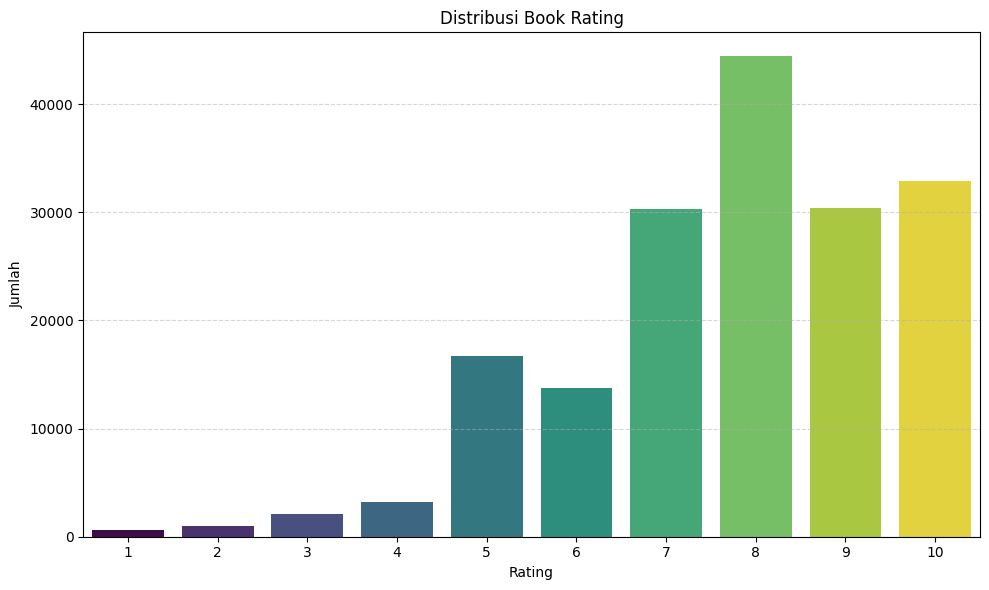

In [54]:
plt.figure(figsize=(10,6))
sns.countplot(data=ratings, x='Book-Rating', hue='Book-Rating', palette='viridis', legend=False)
plt.title('Distribusi Book Rating')
plt.xlabel('Rating')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Interpretasi :**

- Setelah menghapus rating dengan nilai 0, distribusi rating pengguna menunjukkan pola yang condong ke nilai tinggi. Rating 8, 10, dan 7 menjadi yang paling banyak diberikan oleh pengguna, mengindikasikan adanya kecenderungan pengguna untuk memberikan penilaian yang positif terhadap buku yang mereka baca.

- Pembersihan data rating ini membantu menghasilkan distribusi yang lebih merefleksikan preferensi aktual pengguna, karena nilai 0 sebelumnya diduga lebih menggambarkan ketidakterlibatan atau noise daripada opini yang valid.


## Top 10 Buku dengan Rating Terbanyak
- Pada tahap ini dilakukan visualisasi terhadap 10 buku yang memiliki jumlah rating terbanyak dari pengguna.  
- Visualisasi ini bertujuan untuk mengidentifikasi buku-buku yang paling populer atau paling sering dinilai dalam dataset.  
- Informasi ini berguna untuk memahami tren preferensi pengguna dan dapat dijadikan dasar dalam membangun sistem rekomendasi.


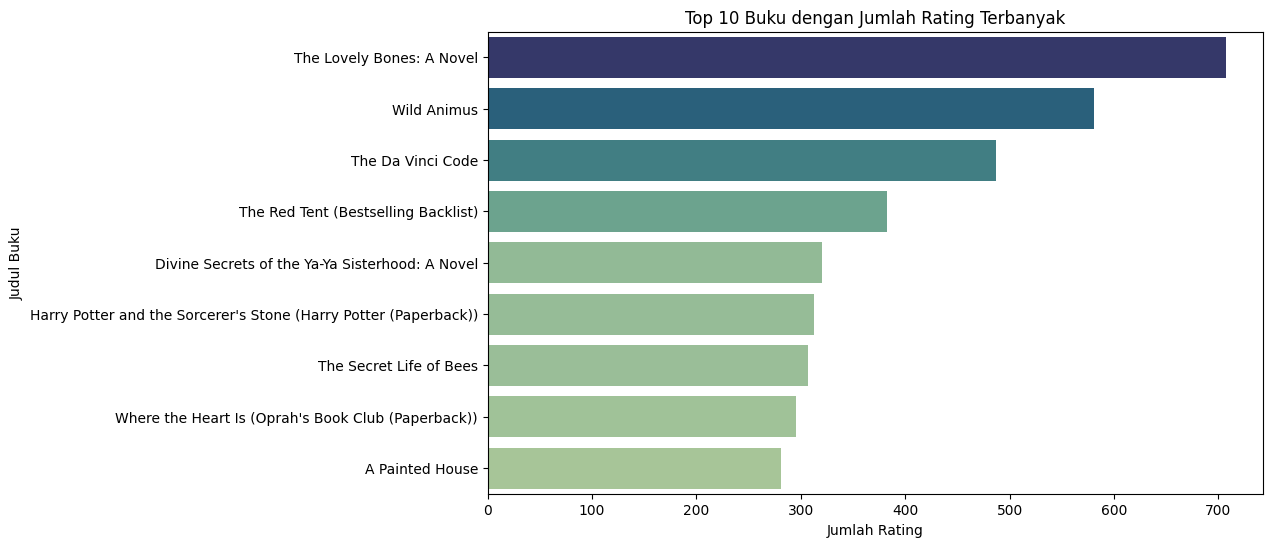

In [55]:
# Mengambil 10 ID buku dengan rating terbanyak
book_counts = ratings['ISBN'].value_counts().head(10)

# Mengambil Judul buku
top_books = book_counts.reset_index()
top_books.columns = ['ISBN', 'Book-Rating']
top_books = top_books.merge(books[['ISBN', 'Book-Title']], on='ISBN', how='left')

plt.figure(figsize=(10, 6))
sns.barplot(x=top_books['Book-Rating'], hue=top_books['Book-Rating'], y=top_books['Book-Title'], palette='crest', legend=False)
plt.xlabel('Jumlah Rating')
plt.ylabel('Judul Buku')
plt.title('Top 10 Buku dengan Jumlah Rating Terbanyak')
plt.show()


**Interpretasi :**
- Berdasarkan data rating yang telah dibersihkan (tanpa rating 0), buku dengan jumlah rating terbanyak adalah:

  - **The Lovely Bones** (~700 rating)
  - **Wild Animus** (~600 rating)
  - **The Da Vinci Code** (~500 rating)
  - **The Red Tent** (~400 rating)

- Meskipun merupakan buku paling populer dalam dataset, jumlah ratingnya masih relatif kecil. Ini menunjukkan bahwa secara umum dataset bersifat **sparse**, yaitu banyak buku yang hanya mendapatkan sedikit interaksi dari pengguna.


## Top 10 User dengan Rating Terbanyak
- Visualisasi ini menampilkan 10 pengguna yang memberikan rating paling banyak terhadap buku.  
- Analisis ini bertujuan untuk mengidentifikasi pengguna yang paling aktif dalam memberikan penilaian.  
- Mengetahui pengguna aktif penting karena mereka dapat memberikan kontribusi besar dalam membentuk kualitas dan arah sistem rekomendasi, serta bisa dijadikan fokus dalam strategi evaluasi model.


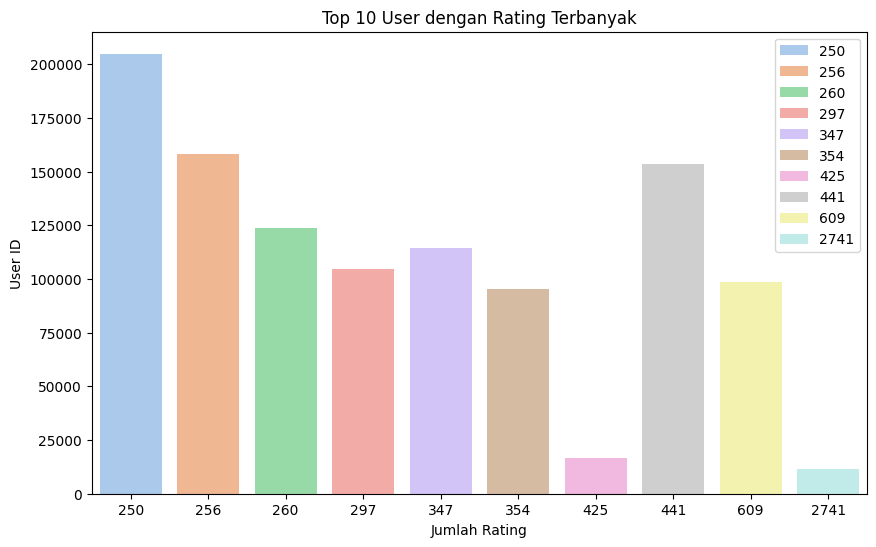

In [56]:
# Hitung jumlah rating per user
user_counts = ratings['User-ID'].value_counts().head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=user_counts.values, hue=user_counts.values, y=user_counts.index, palette='pastel')
plt.xlabel('Jumlah Rating')
plt.ylabel('User ID')
plt.title('Top 10 User dengan Rating Terbanyak')
plt.show()


** INTERPRETASI **
- User dengan ID 250 merupakan pengguna paling aktif, memberikan lebih dari 200.000 rating — jauh lebih tinggi dibanding user lainnya. Ini menunjukkan bahwa user ini sangat dominan dalam kontribusi penilaian.

- User ID 256 dan 441 juga termasuk pengguna sangat aktif, dengan jumlah rating masing-masing di atas 150.000.

- Sementara itu, user lain di urutan bawah (misalnya ID 2741 dan 425) memiliki jumlah rating yang jauh lebih rendah, menunjukkan adanya disparitas aktivitas antar user.

- Distribusi jumlah rating antar user tidak merata — hanya segelintir user yang sangat aktif, sementara sisanya memiliki kontribusi jauh lebih kecil.

#**DATA PREPROCESSING**


## Menggabungkan Data ratings dan book

In [57]:
# contoh gabung ratings + books berdasarkan ISBN
ratings_books = pd.merge(ratings, books, on='ISBN', how='left')

print(ratings_books.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175542 entries, 0 to 175541
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   User-ID              175542 non-null  int64 
 1   ISBN                 175542 non-null  object
 2   Book-Rating          175542 non-null  int64 
 3   Book-Title           169802 non-null  object
 4   Book-Author          169802 non-null  object
 5   Year-Of-Publication  169802 non-null  object
 6   Publisher            169802 non-null  object
 7   Image-URL-S          169802 non-null  object
 8   Image-URL-M          169802 non-null  object
 9   Image-URL-L          169802 non-null  object
dtypes: int64(2), object(8)
memory usage: 13.4+ MB
None


## Mengecek data ratings_book yang bernilai null

In [58]:
ratings_books.isnull().sum()

,0
User-ID,0
ISBN,0
Book-Rating,0
Book-Title,5740
Book-Author,5740
Year-Of-Publication,5740
Publisher,5740
Image-URL-S,5740
Image-URL-M,5740
Image-URL-L,5740


In [59]:
# menghapus yg null
ratings_books.dropna(inplace=True)
ratings_books.isnull().sum()

,0
User-ID,0
ISBN,0
Book-Rating,0
Book-Title,0
Book-Author,0
Year-Of-Publication,0
Publisher,0
Image-URL-S,0
Image-URL-M,0
Image-URL-L,0


### Mengecek data ratings_book yang duplikat


In [60]:
ratings_books.duplicated().sum()

np.int64(0)

### Menghapus beberapa fitur yang tidak diperlukan


In [61]:
ratings_books = ratings_books.drop(columns=['Image-URL-S', 'Image-URL-M', 'Image-URL-L'])
ratings_books

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,276744,038550120X,7,A Painted House,JOHN GRISHAM,2001,Doubleday
1,276747,0060517794,9,Little Altars Everywhere,Rebecca Wells,2003,HarperTorch
2,276747,0671537458,9,Waiting to Exhale,Terry McMillan,1995,Pocket
3,276747,0679776818,8,Birdsong: A Novel of Love and War,Sebastian Faulks,1997,Vintage Books USA
4,276754,0684867621,8,The Girl Who Loved Tom Gordon : A Novel,Stephen King,1999,Scribner
...,...,...,...,...,...,...,...
175537,276688,0836218655,10,Wiener Dog Art,Gary Larson,1990,Andrews McMeel Publishing
175538,276688,0836236688,10,Dilbert: Seven Years Of Highly Defective Peopl...,Scott Adams,1997,Andrews McMeel Publishing
175539,276704,0345386108,6,Winter Moon,Dean R. Koontz,1995,Ballantine Books
175540,276704,0743211383,7,Dreamcatcher,Stephen King,2001,Scribner


In [62]:
fix_book = ratings_books.sort_values('ISBN', ascending=True)
fix_book

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher
80602,123629,0002005018,9,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
138775,219008,0002005018,7,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
134407,210926,0002005018,9,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
77172,116866,0002005018,9,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
7485,11676,0002005018,8,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
...,...,...,...,...,...,...,...
52720,80538,9726101794,3,As mulheres deviam vir com livro de instruÃ§Ãµ...,Manuel Jorge Marmelo,1999,Campo das Letras
164385,257815,9726101794,7,As mulheres deviam vir com livro de instruÃ§Ãµ...,Manuel Jorge Marmelo,1999,Campo das Letras
6336,9016,9726101794,9,As mulheres deviam vir com livro de instruÃ§Ãµ...,Manuel Jorge Marmelo,1999,Campo das Letras
102125,156670,9726101794,5,As mulheres deviam vir com livro de instruÃ§Ãµ...,Manuel Jorge Marmelo,1999,Campo das Letras


In [63]:
# Mengecek berapa jumlah buku yang ada di fix_book
len(fix_book.ISBN.unique())

9540

In [64]:
# Membuat variabel preparation yang berisi dataframe fix_book kemudian mengurutkan berdasarkan ISBN
preparation = fix_book
preparation.sort_values('ISBN')

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher
80602,123629,0002005018,9,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
138775,219008,0002005018,7,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
134407,210926,0002005018,9,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
77172,116866,0002005018,9,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
7485,11676,0002005018,8,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
...,...,...,...,...,...,...,...
115763,178797,9726101794,8,As mulheres deviam vir com livro de instruÃ§Ãµ...,Manuel Jorge Marmelo,1999,Campo das Letras
52720,80538,9726101794,3,As mulheres deviam vir com livro de instruÃ§Ãµ...,Manuel Jorge Marmelo,1999,Campo das Letras
164385,257815,9726101794,7,As mulheres deviam vir com livro de instruÃ§Ãµ...,Manuel Jorge Marmelo,1999,Campo das Letras
6336,9016,9726101794,9,As mulheres deviam vir com livro de instruÃ§Ãµ...,Manuel Jorge Marmelo,1999,Campo das Letras


In [65]:
# Membuang data duplikat pada variabel preparation
preparation = preparation.drop_duplicates('ISBN')
preparation

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher
80602,123629,0002005018,9,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
173929,274004,0002251760,10,The Forgetting Room: A Fiction (Byzantium Book),Nick Bantock,1997,Harpercollins
93833,142745,0002259834,7,Miss Wyoming Uk Edition,Douglas Coupland,0,Harpercollins Publisher
150179,236173,0002558122,9,Angelas Ashes,Frank Mccourt,0,Harpercollins Australia
17964,24878,0006480764,4,Lost Girls,Andrew Pyper,0,Harperperennial
...,...,...,...,...,...,...,...
137156,216444,9074336329,8,Want dit is mijn lichaam,Renate Dorrestein,1997,Contact
86071,131126,950491036X,10,La Sombra del Viento,Carlos Ruiz Zafon,2003,Planeta
120116,186736,9681500555,5,Diario de Ana Frank,Anne Frank,2000,"Editores Mexicanos Unidos, S.A."
138394,218515,9681501225,8,Siddharta (Mexican Edition),Hermann Hesse,1998,"Editorial Diana, S.A."


In [66]:
# Mengonversi data series ‘ISBN’ menjadi dalam bentuk list
book_id = preparation['ISBN'].tolist()

# Mengonversi data series ‘Book-Title' menjadi dalam bentuk list
book_title = preparation['Book-Title'].tolist()

# Mengonversi data series ‘Book-Author’ menjadi dalam bentuk list
book_author = preparation['Book-Author'].tolist()

# Mengonversi data series ‘Publisher’ menjadi dalam bentuk list
book_publisher = preparation['Publisher'].tolist()

print(len(book_id))
print(len(book_author))
print(len(book_title))
print(len(book_publisher))

9540
9540
9540
9540


In [67]:
# Membuat dictionary untuk data ‘book_id’, ‘book_title’, dan ‘book_author’, dan 'book_publisher'
book_new = pd.DataFrame({
    'id': book_id,
    'title': book_title,
    'author': book_author,
    'publisher': book_publisher
})
book_new

,id,title,author,publisher
0,0002005018,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada
1,0002251760,The Forgetting Room: A Fiction (Byzantium Book),Nick Bantock,Harpercollins
2,0002259834,Miss Wyoming Uk Edition,Douglas Coupland,Harpercollins Publisher
3,0002558122,Angelas Ashes,Frank Mccourt,Harpercollins Australia
4,0006480764,Lost Girls,Andrew Pyper,Harperperennial
...,...,...,...,...
9535,9074336329,Want dit is mijn lichaam,Renate Dorrestein,Contact
9536,950491036X,La Sombra del Viento,Carlos Ruiz Zafon,Planeta
9537,9681500555,Diario de Ana Frank,Anne Frank,"Editores Mexicanos Unidos, S.A."
9538,9681501225,Siddharta (Mexican Edition),Hermann Hesse,"Editorial Diana, S.A."


In [68]:
book_new['combined_features'] = book_new['author'] + ' ' + book_new['publisher']


# MODEL DEVELOPMENT DENGAN CONTENT BASED FILTERING

In [69]:
data = book_new

## Inisialisasi TfidfVectorizer

In [70]:
tfidf = TfidfVectorizer()

tfidf.fit(data['combined_features'])
tfidf.get_feature_names_out()

array(['10', '12', '18', ..., 'â¼rich', 'â¼rrenmatt', 'â¼skind'],
      dtype=object)

In [71]:
# Melakukan fit lalu ditransformasikan ke bentuk matrix
tfidf_matrix = tfidf.fit_transform(data['combined_features'])

tfidf_matrix.shape

(9540, 4050)

In [72]:
# Mengubah vektor tf-idf dalam bentuk matriks dengan fungsi todense()
tfidf_matrix.todense()

matrix([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]])

In [73]:
# Membuat dataframe untuk melihat tf-idf matrix

pd.DataFrame(
    tfidf_matrix.todense(),
    columns=tfidf.get_feature_names_out(),
    index=data.title
).sample(22, axis=1).sample(10, axis=0)

,modern,berg,mildred,safire,bel,ryrie,linda,classics,ctor,esther,...,dahl,pasternak,choderlos,sawyer,piper,bolen,snicket,olivia,collectors,meg
title,,,,,,,,,,,,,,,,,,,,,
El lÃ¡piz del carpintero,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Worst Fears Realized,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Voices in Summer,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
After All These Years,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Something Wicked This Way Comes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
She Went All the Way (Avon Light Contemporary Romances),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Uh-Oh: Some Observations from Both Sides of the Refrigerator Door,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Flight,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Fire Ice: A Novel from the Numa Files (Kurt Austin Adventures (Paperback)),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Menghitung nilai Cosine Similarity

In [74]:
cosine_sim = cosine_similarity(tfidf_matrix)
cosine_sim

array([[1.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.15626832, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.15626832, 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 1.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        1.        ]])

In [75]:
# Membuat dataframe dari variabel cosine_sim dengan baris dan kolom berupa Judul Buku
cosine_sim_df = pd.DataFrame(cosine_sim, index=data['title'], columns=data['title'])
print('Shape:', cosine_sim_df.shape)

# Melihat similarity matrix pada setiap buku
cosine_sim_df.sample(5, axis=1).sample(10, axis=0)

Shape: (9540, 9540)


title,Moonlight on the Avenue of Faith,The Thomas Berryman Number,The Tenth Justice,Merry Christmas Mom and Dad (A Golden Look-Look Book),The Catcher in the Rye
title,,,,,
Sati,0.0,0.044672,0.033133,0.027883,0.032915
High Maintenance,0.0,0.000000,0.000000,0.000000,0.000000
The First Counsel,0.0,0.205206,1.000000,0.025390,0.029972
"Good Night, Gorilla",0.0,0.000000,0.000000,0.000000,0.000000
Dunkle Kammern.,0.0,0.000000,0.000000,0.000000,0.000000
Anonymous Rex: A Detective Story,0.0,0.039452,0.029261,0.024625,0.029069
Abuse of Power,0.0,0.000000,0.000000,0.000000,0.000000
Sabriel (The Abhorsen Trilogy),0.0,0.000000,0.000000,0.000000,0.000000
Mistletoe Man,0.0,0.000000,0.000000,0.000000,0.000000


In [76]:
def book_recommendations(judul_buku, similarity_data=cosine_sim_df, items=data[['title', 'combined_features']], k=5):
    index = similarity_data.loc[:,judul_buku].to_numpy().argpartition(
        range(-1, -k, -1))

    closest = similarity_data.columns[index[-1:-(k+2):-1]]
    closest = closest.drop(judul_buku, errors='ignore')

    return pd.DataFrame(closest).merge(items).head(k)

In [77]:
data[data.title.eq('Shades Of Twilight')]

,id,title,author,publisher,combined_features
6600,0671019716,Shades Of Twilight,Linda Howard,Pocket,Linda Howard Pocket


In [78]:
book_recommendations('Shades Of Twilight')

,title,combined_features
0,Son of the Morning,Linda Howard Pocket
1,Strangers in the Night,Linda Howard Pocket
2,Open Season,Linda Howard Pocket
3,Everlasting Love,Linda Howard Pocket
4,Dying to Please,LINDA HOWARD Ballantine Books


## EVALUASI KUANTITATIF CONTENT-BASED FILTERING
- Menggunakan metrik: Precision@5 dan Recall@5
- Dataset test diambil dari 20% interaksi user di data rating

In [79]:
# Bagi data rating ke train dan test
train_data, test_data = train_test_split(ratings_books, test_size=0.2, random_state=42)

# Buat dict: user_id -> list of actual relevant books di test set
actual_relevant = (
    test_data[test_data['Book-Rating'] >= 7]  # threshold relevan
    .groupby('User-ID')['Book-Title']
    .apply(set)
    .to_dict()
)


In [80]:
def precision_recall_at_k(k=5):
    precisions = []
    recalls = []
    users_evaluated = 0

    for user_id in actual_relevant:
        # Buku yang sudah pernah dibaca user
        read_books = set(train_data[train_data['User-ID'] == user_id]['Book-Title'])

        # Pilih salah satu buku yang dibaca sebagai "anchor"
        candidate_books = list(read_books)
        if not candidate_books:
            continue

        anchor_book = candidate_books[0]

        try:
            recommendations = book_recommendations(anchor_book, k=k)
            predicted = set(recommendations['title'].values)
            actual = actual_relevant[user_id]

            if len(actual) == 0:
                continue

            precision = len(predicted & actual) / k
            recall = len(predicted & actual) / len(actual)

            precisions.append(precision)
            recalls.append(recall)
            users_evaluated += 1
        except:
            continue

    print(f"Evaluated {users_evaluated} users.")
    print(f"Average Precision@{k}: {np.mean(precisions):.4f}")
    print(f"Average Recall@{k}: {np.mean(recalls):.4f}")


In [81]:
# Evaluasi kuantitatif Content-Based Filtering
precision_recall_at_k(k=5)

Evaluated 6055 users.
Average Precision@5: 0.0118
Average Recall@5: 0.0323


 INTERPRETASI
- Nilai Precision@5 sebesar 0.0118 dan Recall@5 sebesar 0.0323 menunjukkan bahwa hanya sebagian kecil dari rekomendasi yang benar-benar sesuai dengan preferensi pengguna. Ini mengindikasikan bahwa model Content-Based Filtering masih kurang akurat dalam mengenali relevansi buku. Penyebab utamanya kemungkinan karena fitur konten yang digunakan terlalu terbatas (hanya penulis dan penerbit), sehingga kurang mampu menangkap konteks preferensi yang lebih dalam. Meski begitu, hasil ini tetap berguna sebagai baseline awal sebelum dikembangkan lebih lanjut.



# MODEL DEVELOPMENT DENGAN COLLABORATIVE FILTERING

In [82]:
df = ratings
df

,User-ID,ISBN,Book-Rating
8,276744,038550120X,7
16,276747,0060517794,9
19,276747,0671537458,9
20,276747,0679776818,8
28,276754,0684867621,8
...,...,...,...
1149743,276688,0836218655,10
1149744,276688,0836236688,10
1149761,276704,0345386108,6
1149771,276704,0743211383,7


In [83]:
# ngeresample df baru berdasarkan data yg ada udah di resample di dataframe data
df['ISBN'] = df['ISBN'].astype(str)
data['id'] = data['id'].astype(str)

# Filter df hanya untuk ISBN yang ada di book_fix
df = df[df['ISBN'].isin(data['id'])]

In [84]:
# Menyimpan dataset rating yang fiks ke csv
df.to_csv('rating_final.csv', index=False)

## Encoding ID user

In [85]:
# Mengubah userID menjadi list tanpa nilai yang sama
user_ids = df['User-ID'].unique().tolist()
print('list User-ID: ', user_ids)

# Melakukan encoding userID
user_to_user_encoded = {x: i for i, x in enumerate(user_ids)}
print('encoded userID : ', user_to_user_encoded)

# Melakukan proses encoding angka ke ke userID
user_encoded_to_user = {i: x for i, x in enumerate(user_ids)}
print('encoded angka ke userID: ', user_encoded_to_user)

list User-ID:  [276744, 276747, 276754, 276755, 276762, 276772, 276788, 276796, 276798, 276804, 276811, 276822, 276828, 276830, 276832, 276837, 276847, 276850, 276859, 276861, 276866, 276872, 276875, 276887, 276896, 276904, 276905, 276911, 276925, 276928, 276929, 276936, 276939, 276953, 276957, 276964, 276986, 276988, 276994, 276998, 277012, 277018, 277028, 277031, 277032, 277036, 277042, 277048, 277051, 277072, 277085, 277087, 277094, 277096, 277107, 277109, 277124, 277135, 277139, 277143, 277157, 277168, 277170, 277171, 277179, 277187, 277188, 277189, 277195, 277196, 277197, 277203, 277205, 277212, 277220, 277228, 277229, 277230, 277235, 277237, 277243, 277246, 277253, 277257, 277261, 277265, 277272, 277281, 277284, 277292, 277293, 277314, 277315, 277317, 277341, 277348, 277363, 277364, 277367, 277374, 277378, 277397, 277402, 277427, 277435, 277436, 277439, 277444, 277462, 277466, 277469, 277470, 277471, 277473, 277474, 277478, 277502, 277506, 277508, 277509, 277517, 277519, 277523, 

## Encoding ID book ( ISBN )

In [86]:
# Mengubah ISBN menjadi list tanpa nilai yang sama
book_ids = df['ISBN'].unique().tolist()

# Melakukan proses encoding placeID
book_to_book_encoded = {x: i for i, x in enumerate(book_ids)}

# Melakukan proses encoding angka ke placeID
book_encoded_to_book = {i: x for i, x in enumerate(book_ids)}


## Mapping user-id dan book-id ke dataframe df

In [87]:
df['user'] = df['User-ID'].map(user_to_user_encoded)
df['book'] = df['ISBN'].map(book_to_book_encoded)

<ipython-input-87-1844707915>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['user'] = df['User-ID'].map(user_to_user_encoded)
<ipython-input-87-1844707915>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['book'] = df['ISBN'].map(book_to_book_encoded)


In [88]:
df = df.copy()

# Mendapatkan jumlah user
num_users = len(user_to_user_encoded)
print(num_users)

# Mendapatkan jumlah resto
num_book = len(book_encoded_to_book)
print(num_book)

# Mengubah rating menjadi nilai float
df['Book-Rating'] = df['Book-Rating'].values.astype(np.float32)

# Nilai minimum rating
min_rating = min(df['Book-Rating'])

# Nilai maksimal rating
max_rating = max(df['Book-Rating'])

print('Number of User: {}, Number of Resto: {}, Min Rating: {}, Max Rating: {}'.format(
    num_users, num_book, min_rating, max_rating
))

44147
9540
Number of User: 44147, Number of Resto: 9540, Min Rating: 1.0, Max Rating: 10.0


## Shuffle dataset

In [89]:
df = df.sample(frac=1, random_state=42)
df

,User-ID,ISBN,Book-Rating,user,book
506848,123430,0312979975,9.0,19906,5816
960134,231993,0679442790,7.0,36995,1056
835232,201768,0449149900,10.0,32165,4685
380268,91886,0345453743,9.0,14901,4329
353585,85278,0099245027,6.0,13913,4163
...,...,...,...,...,...
798974,193744,0440226198,10.0,31005,6753
679498,165319,067151699X,7.0,26565,5422
891564,215143,0140620753,9.0,34339,9079
995047,238781,0743406184,10.0,38123,8389


## Membagi Data untuk Training dan Validasi

In [90]:
x = df[['user', 'book']].values
y = df['Book-Rating'].apply(lambda x: (x - min_rating) / (max_rating - min_rating)).values

train_indices = int(0.8 * df.shape[0])
x_train, x_val, y_train, y_val = (
    x[:train_indices],
    x[train_indices:],
    y[:train_indices],
    y[train_indices:]
)

print(x, y)

[[19906  5816]
 [36995  1056]
 [32165  4685]
 ...
 [34339  9079]
 [38123  8389]
 [31561  1347]] [0.88888889 0.66666667 1.         ... 0.88888889 1.         0.88888889]


## Membuat class RecommenderNet

In [91]:
class RecommenderNet(tf.keras.Model):
  def __init__(self, num_users, num_book, embedding_size, **kwargs):
    super(RecommenderNet, self).__init__(**kwargs)
    self.num_users = num_users
    self.num_resto = num_book
    self.embedding_size = embedding_size
    self.user_embedding = layers.Embedding(
        num_users,
        embedding_size,
        embeddings_initializer = 'he_normal',
        embeddings_regularizer = keras.regularizers.l2(1e-6)
    )
    self.user_bias = layers.Embedding(num_users, 1)
    self.book_embedding = layers.Embedding(
        num_book,
        embedding_size,
        embeddings_initializer = 'he_normal',
        embeddings_regularizer = keras.regularizers.l2(1e-6)
    )
    self.book_bias = layers.Embedding(num_book, 1)

  def call(self, inputs):
    user_vector = self.user_embedding(inputs[:,0])
    user_bias = self.user_bias(inputs[:, 0])
    book_vector = self.book_embedding(inputs[:, 1])
    book_bias = self.book_bias(inputs[:, 1])

    dot_user_book = tf.tensordot(user_vector, book_vector, 2)

    x = dot_user_book + user_bias + book_bias

    return x

## Inisialisasi Model

In [92]:
model = RecommenderNet(num_users, num_book, 50)

model.compile(
    loss='mse',
    optimizer='adam',
    metrics=['mae']
)

## Training Model

In [93]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


history = model.fit(
    x = x_train,
    y = y_train,
    batch_size = 8,
    epochs = 50,
    validation_data = (x_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/50
16981/16981 ━━━━━━━━━━━━━━━━━━━━ 57s 3ms/step - loss: 0.3621 - mae: 0.5356 - val_loss: 0.0935 - val_mae: 0.2392
Epoch 2/50
16981/16981 ━━━━━━━━━━━━━━━━━━━━ 52s 3ms/step - loss: 0.0977 - mae: 0.2417 - val_loss: 0.0995 - val_mae: 0.2496
Epoch 3/50
16981/16981 ━━━━━━━━━━━━━━━━━━━━ 83s 3ms/step - loss: 0.1082 - mae: 0.2549 - val_loss: 0.0938 - val_mae: 0.2401
Epoch 4/50
16981/16981 ━━━━━━━━━━━━━━━━━━━━ 50s 3ms/step - loss: 0.1107 - mae: 0.2562 - val_loss: 0.0898 - val_mae: 0.2332
Epoch 5/50
16981/16981 ━━━━━━━━━━━━━━━━━━━━ 82s 3ms/step - loss: 0.1064 - mae: 0.2515 - val_loss: 0.0869 - val_mae: 0.2292
Epoch 6/50
16981/16981 ━━━━━━━━━━━━━━━━━━━━ 83s 3ms/step - loss: 0.1040 - mae: 0.2483 - val_loss: 0.0815 - val_mae: 0.2201
Epoch 7/50
16981/16981 ━━━━━━━━━━━━━━━━━━━━ 50s 3ms/step - loss: 0.0977 - mae: 0.2400 - val_loss: 0.0774 - val_mae: 0.2145
Epoch 8/50
16981/16981 ━━━━━━━━━━━━━━━━━━━━ 82s 3ms/step - loss: 0.0916 - mae: 0.2314 - val_loss: 0.0744 - val_mae: 0.2094
Epoch 9/50
16981

## Membuat visualisasi Metrik

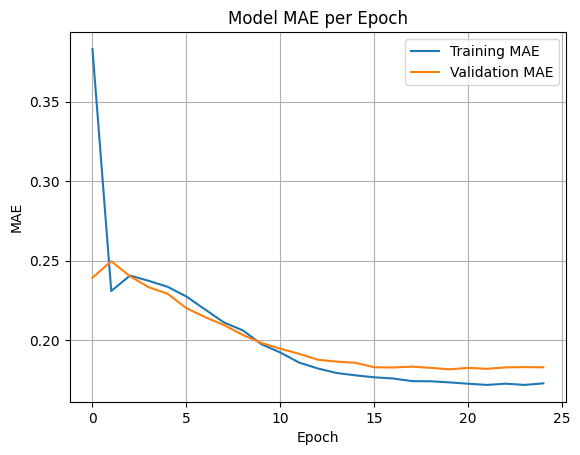

In [94]:
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE per Epoch')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()

## Insight :
1. Performa Meningkat di Awal
Pada beberapa epoch pertama, MAE menurun signifikan baik pada data training maupun validasi. Hal ini menunjukkan bahwa model cepat belajar pola dalam data.

2. Konsistensi Antara Training dan Validation
Sepanjang pelatihan, garis MAE training dan validation saling berdekatan, artinya model memiliki generalisasi yang baik (tidak hanya menghafal data training).

## Mendapatkan Rekomendasi Buku

In [95]:
book_df = book_new
df = pd.read_csv('rating_final.csv')

# Mengambil sample user
user_id = df['User-ID'].sample(1).iloc[0]
book_has_read_by_user = df[df['User-ID'] == user_id]

book_has_not_read = book_df[~book_df['id'].isin(book_has_read_by_user.ISBN.values)]['id']
book_has_not_read = list(
    set(book_has_not_read)
    .intersection(set(book_to_book_encoded.keys()))
)

book_has_not_read = [[book_to_book_encoded.get(x)] for x in book_has_not_read]
user_encoder = user_to_user_encoded.get(user_id)
user_book_array = np.hstack(
    ([[user_encoder]] * len(book_has_not_read), book_has_not_read)
)

In [96]:
ratings = model.predict(user_book_array).flatten()

top_ratings_indices = ratings.argsort()[-10:][::-1]
recommended_book_ids = [
    book_encoded_to_book.get(book_has_not_read[x][0]) for x in top_ratings_indices
]

print('Showing recommendations for users: {}'.format(user_id))
print('===' * 9)
print('Book with high ratings from user')
print('----' * 8)

top_resto_user = (
    book_has_read_by_user.sort_values(
        by = 'Book-Rating',
        ascending=False
    )
    .head(5)
    .ISBN.values
)

book_df_rows = book_df[book_df['id'].isin(top_resto_user)]
for row in book_df_rows.itertuples():
    print(row.title, ':', row.author, ' dan ', row.publisher)

print('----' * 8)
print('Top 10 Books recommendation')
print('----' * 8)

recommended_book = book_df[book_df['id'].isin(recommended_book_ids)]
for row in recommended_book.itertuples():
    print(row.title, ':', row.author, ' dan ', row.publisher)

297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Showing recommendations for users: 49460
Book with high ratings from user
--------------------------------
The Eyre Affair: A Novel : Jasper Fforde  dan  Penguin Books
Pride and Prejudice (Oxford World's Classics) : Jane Austen  dan  Oxford University Press
The Amazing Adventures of Kavalier &amp; Clay : Michael Chabon  dan  Picador
The Corrections: A Novel : Jonathan Franzen  dan  Picador USA
The Far Side Observer : Gary Larson  dan  Andrews McMeel Publishing
--------------------------------
Top 10 Books recommendation
--------------------------------
The Magician's Nephew (Narnia) : C. S. Lewis  dan  HarperTrophy
The Blue Day Book: A Lesson in Cheering Yourself Up : Bradley Trevor Greive  dan  Random House Australia
Dharma Bums : Jack Kerouac  dan  Penguin Books
Songlines : Bruce Chatwin  dan  Pan Books Ltd
Big Stone Gap : A Novel : ADRIANA TRIGIANI  dan  Random House
Exit Wounds : A Novel of Suspense (Jance, Ja) : J. A. Jance  dan  William Mo